<a href="https://colab.research.google.com/github/AndrewLoweUoM/Hydrological_Analysis/blob/main/Multiple_Event_Analysis_Peaks_Timings_Lags_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description of Code


This code performs a multi-event hydrological analysis using aligned flow events, including:

* Visualisation of multiple hydrographs
* Extraction of key event metrics (peaks, rainfall, lag times)
* Statistical summaries across events
* Rainfall–runoff relationship analysis
* Distribution analysis of peak flows.


Overall, this code implements a full multi-event hydrological analysis pipeline, extracting peak flow, rainfall characteristics, and lag times (including centroid-based metrics), analysing relationships and distributions across events, and producing outputs suitable for comparative studies such as evaluating NFM impacts.

# Data Loading & Exploration

* Loads a wide-format CSV (multi-event, column-based) of adjusted events:
   * Event001_Time, Event001_Flow, Event001_Rain,
* Each event is stored as a separate set of columns.

* Checks:
  * Shape, columns
  * Head/tail preview
  * Missing values and stats are present

### Prepare and load data into Dataframe

In [ ]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the event data for all events
file_path ='/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Oak_storm_event_timeseries_23_events_adjusted.csv'
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted.csv'
# Load the event data for events before NFM
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted_before.csv'
# Load the event data for events after NFM
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted_after.csv'

df_events = pd.read_csv(file_path)
# Displays start data in the Dataframe
df_events.head()

,Time,Event001_Time,Event001_Rain,Event001_Flow,Event001_Baseflow,Event002_Time,Event002_Rain,Event002_Flow,Event002_Baseflow,Event003_Time,...,Event020_Flow,Event020_Baseflow,Event021_Time,Event021_Rain,Event021_Flow,Event021_Baseflow,Event022_Time,Event022_Rain,Event022_Flow,Event022_Baseflow
0,1,26/07/2023 20:30,1.4,11.0,9.3,02/08/2023 03:15,0.6,17.4,14.7,14/08/2023 09:45,...,26.5,20.4,22/05/2024 09:30,0.4,8.2,7.1,09/06/2024 19:15,0.2,10.7,9.0
1,2,26/07/2023 20:45,1.6,11.6,9.3,02/08/2023 03:30,1.0,18.1,14.4,14/08/2023 10:00,...,27.3,20.4,22/05/2024 09:45,0.6,10.2,7.1,09/06/2024 19:30,0.4,11.3,9.0
2,3,26/07/2023 21:00,1.2,11.9,9.3,02/08/2023 03:45,0.2,20.5,14.4,14/08/2023 10:15,...,28.3,20.4,22/05/2024 10:00,7.6,10.6,7.1,09/06/2024 19:45,0.6,12.1,9.0
3,4,26/07/2023 21:15,0.8,12.0,9.3,02/08/2023 04:00,0.2,23.0,14.4,14/08/2023 10:30,...,30.0,20.4,22/05/2024 10:15,1.0,11.9,7.1,09/06/2024 20:00,0.6,11.6,9.0
4,5,26/07/2023 21:30,0.4,12.6,9.3,02/08/2023 04:15,0.2,25.3,14.2,14/08/2023 10:45,...,24.7,20.4,22/05/2024 10:30,0.8,10.6,7.1,09/06/2024 20:15,1.2,12.3,9.0


### Display DataFrame Dimensions, Check Missing Values, and Describe Statistics

In [ ]:
# Displays end data in the Dataframe
df_events.tail()

,Time,Event001_Time,Event001_Rain,Event001_Flow,Event001_Baseflow,Event002_Time,Event002_Rain,Event002_Flow,Event002_Baseflow,Event003_Time,...,Event020_Flow,Event020_Baseflow,Event021_Time,Event021_Rain,Event021_Flow,Event021_Baseflow,Event022_Time,Event022_Rain,Event022_Flow,Event022_Baseflow
601,602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
602,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
603,604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
604,605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
605,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
## Display summary of the DataFrame
print(df_events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 89 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               606 non-null    int64  
 1   Event001_Time      231 non-null    object 
 2   Event001_Rain      231 non-null    float64
 3   Event001_Flow      231 non-null    float64
 4   Event001_Baseflow  231 non-null    float64
 5   Event002_Time      207 non-null    object 
 6   Event002_Rain      207 non-null    float64
 7   Event002_Flow      207 non-null    float64
 8   Event002_Baseflow  207 non-null    float64
 9   Event003_Time      159 non-null    object 
 10  Event003_Rain      159 non-null    float64
 11  Event003_Flow      159 non-null    float64
 12  Event003_Baseflow  162 non-null    float64
 13  Event004_Time      124 non-null    object 
 14  Event004_Rain      124 non-null    float64
 15  Event004_Flow      124 non-null    float64
 16  Event004_Baseflow  125 non

In [ ]:
# Displays DataFrame dimensions (rows and columns)
print('Shape of data:', df_events.shape)

Shape of data: (606, 89)


In [ ]:
# Displays all columnns in the DataFrame
#print(df_events.columns)

In [ ]:
# Check for missing values in the DataFrame
#print(df_events.isnull().sum())

In [ ]:
#replace null values with 0
# df_events.fillna(0, inplace=True)

In [ ]:
# Display summary statistics of the DataFrame
#print(df_events.describe())

# Specify the Number of Flood Hydrograph Events

In [ ]:
# Number of flood hydrograph events (Event 1 assigned Event ID 0 e.g. for 53 events N = 52 )
#N = 52
N = 21

# Multi-Event Visualisation

### Flow Comparison

* Plots all event hydrographs (Time Index):

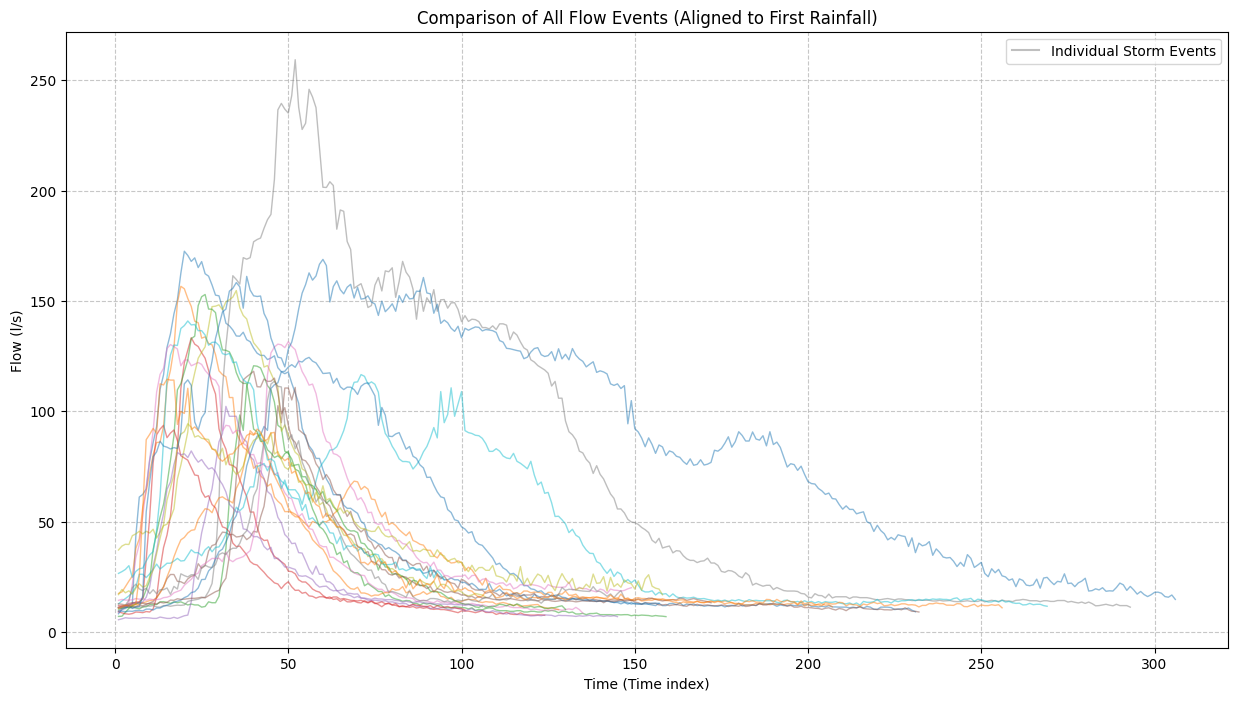

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for the plot
plt.figure(figsize=(15, 8))

# Identify flow columns in the adjusted dataframe
flow_cols = [col for col in df_events.columns if col.endswith('_Flow')]

# Loop through and plot each event's flow
for col in flow_cols:
    # We plot against the 'Time' column which now represents relative steps from start of rain (Time is a Time index which is the number of 15 mins)
    plt.plot(df_events['Time'], df_events[col], alpha=0.5, linewidth=1, label='_nolegend_')

# Add labels and title
plt.xlabel('Time (Time index)')
plt.ylabel('Flow (l/s)')
plt.title('Comparison of All Flow Events (Aligned to First Rainfall)')

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add a generic legend entry for the events
plt.plot([], [], color='gray', alpha=0.5, label='Individual Storm Events')
plt.legend()

plt.show()

### Flow Comparison

* Plots all event hydrographs (hours):

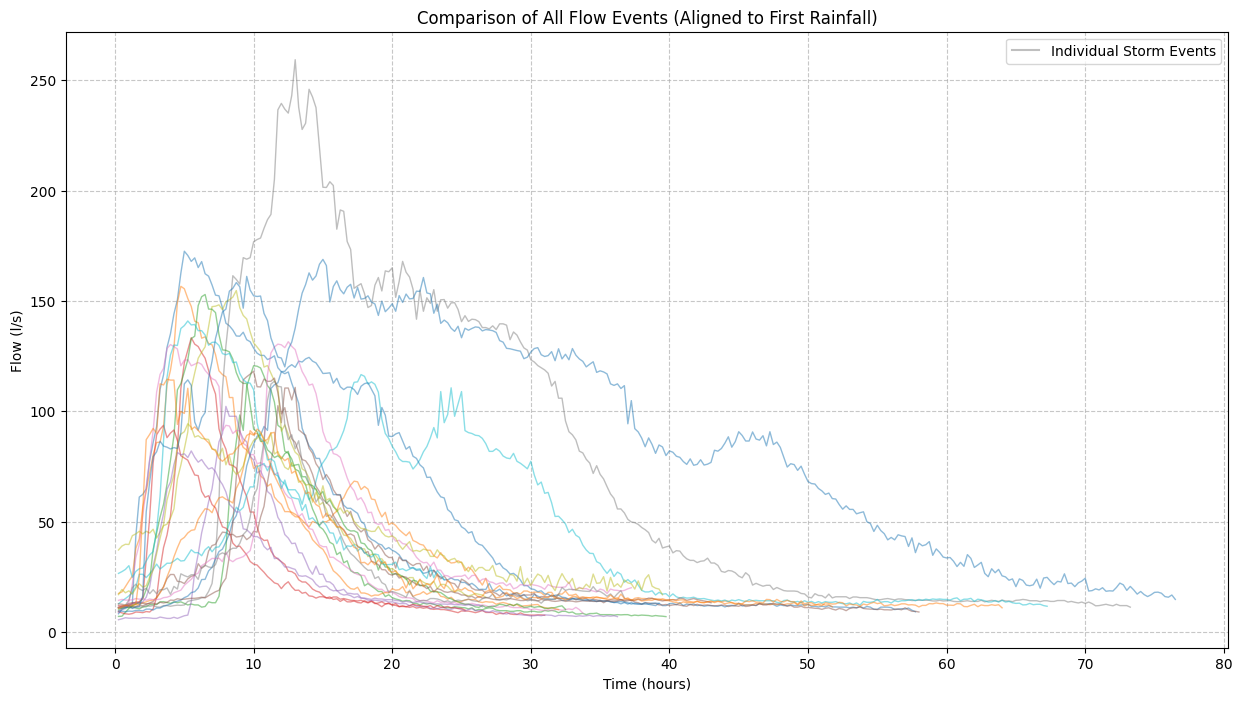

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for the plot
plt.figure(figsize=(15, 8))

# Identify flow columns in the adjusted dataframe
flow_cols = [col for col in df_events.columns if col.endswith('_Flow')]

# Loop through and plot each event's flow
for col in flow_cols:
    # We plot against the 'Time' column which now represents relative steps from start of rain (Time has timestep 15 mins and divided by 4 to get hours)
    plt.plot(df_events['Time'] / 4, df_events[col], alpha=0.5, linewidth=1, label='_nolegend_')

# Add labels and title
plt.xlabel('Time (hours)')
plt.ylabel('Flow (l/s)')
plt.title('Comparison of All Flow Events (Aligned to First Rainfall)')

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add a generic legend entry for the events
plt.plot([], [], color='gray', alpha=0.5, label='Individual Storm Events')
plt.legend()

plt.show()

### Rainfall Comparision

Plot Rainfall for All Events (bar charts - Time Index )

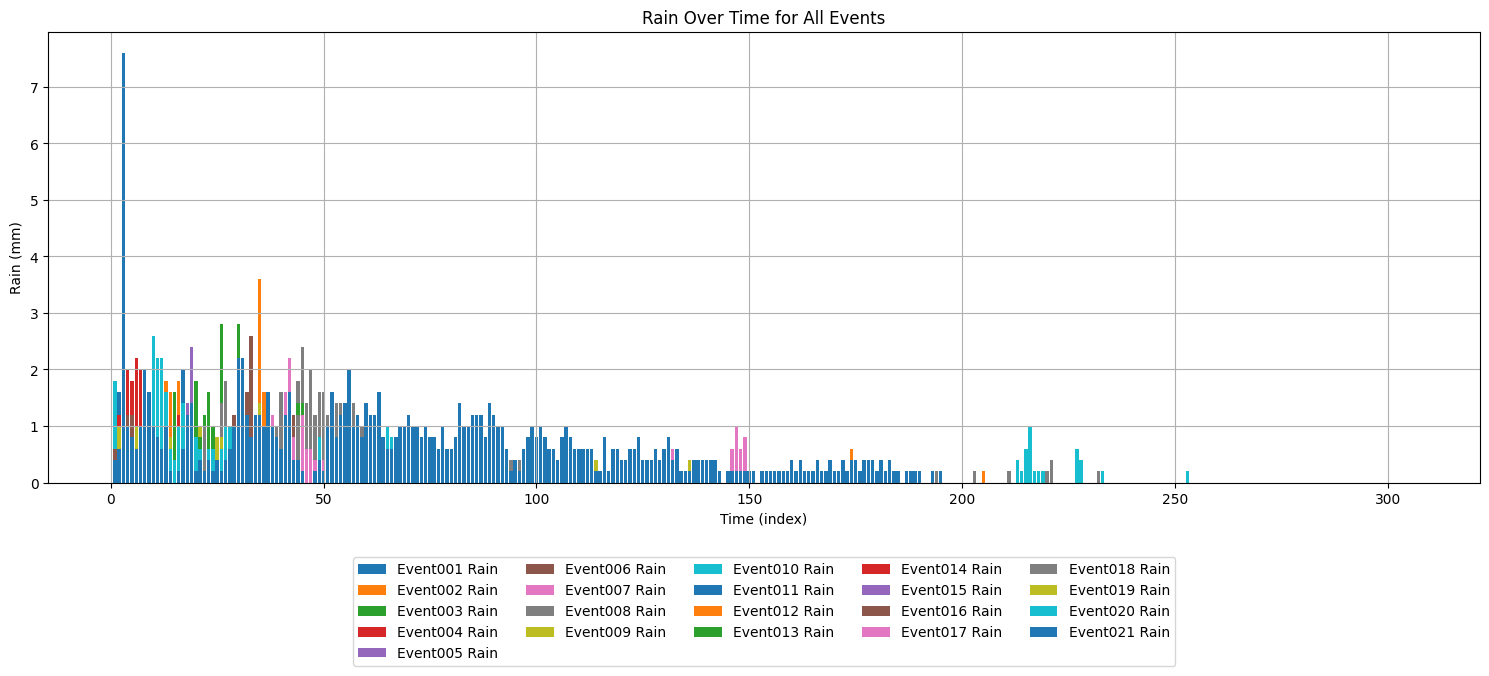

In [ ]:
# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(15, 7))

# Loop through all events and plot their rain data
for i in range(1, N):
    rain_col_name = f'Event{i:03d}_Rain'

    # Check if the column exists in df_events and has valid data
    if rain_col_name in df_events.columns and not df_events[rain_col_name].isnull().all():
        ax.bar(df_events['Time'], df_events[rain_col_name], label=f'Event{i:03d} Rain')

# Set labels and title for the plot
ax.set_xlabel('Time (index)')
ax.set_ylabel('Rain (mm)')
ax.set_title('Rain Over Time for All Events')

# Add a legend to differentiate the events

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)

plt.grid(True)
plt.tight_layout()
plt.show()

### Rainfall Comparison

* Plots rainfall for all events (bar charts - Hours e.g. Time Index / 4)

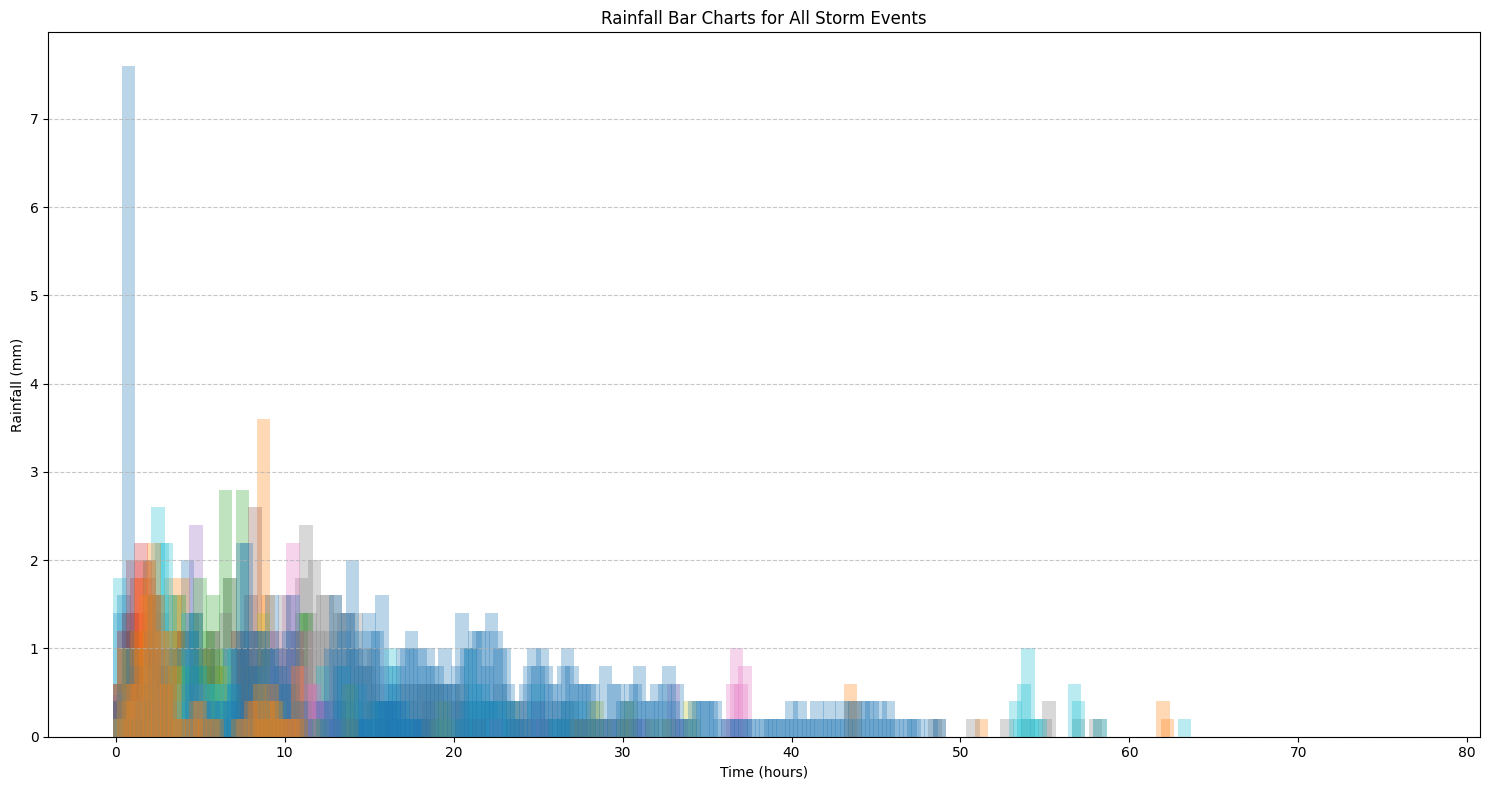

In [ ]:
import matplotlib.pyplot as plt

# Filter for rainfall columns
rain_columns = [col for col in df_events.columns if col.endswith('_Rain')]

# Create a figure
plt.figure(figsize=(15, 8))

# Plot each event's rainfall as a bar chart whereby Time is a Time Index and is divided by 4 to get hours from 15 minute data
for col in rain_columns:
    plt.bar(df_events['Time'] / 4, df_events[col], alpha=0.3, label='_nolegend_')

plt.title('Rainfall Bar Charts for All Storm Events')
plt.xlabel('Time (hours)')
plt.ylabel('Rainfall (mm)')
#plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Multi-Event Hydrological Metrics Extraction

### Loop Through Events

For each event:

* Extract:
  * Flow
  * Rainfall
  * Time

Metrics Computed Per Event

* Flow Metrics
  * Peak flow value
  * Time of peak flow

* Rainfall Metrics
  * Total rainfall
  * Peak rainfall (overall)
  * Peak rainfall before flow peak
  * Total rainfall before flow peak

* Timing Metrics
  * Lag time:
    * Peak rainfall → peak flow

* Centroid Metrics
  * Rainfall centroid (before peak flow)
  * Centroid-based lag time


### Calculate Peak Flow and Rainfall and Time and Lag Time

In [ ]:
import pandas as pd
import numpy as np

# List to store results for all events
all_event_peak_data = []

print(f"Processing {N-1} storm events...")

# Loop through all events (from Event001 to Event0XX)
for i in range(1, N):
    flow_col_name = f'Event{i:03d}_Flow'
    rain_col_name = f'Event{i:03d}_Rain'
    date_col_name = f'Event{i:03d}_Time'

    event_name = f'Event{i:03d}'

    # Check if the required columns exist and are not entirely null for this event
    if (flow_col_name in df_events.columns and not df_events[flow_col_name].isnull().all() and
        date_col_name in df_events.columns and not df_events[date_col_name].isnull().all() and
        rain_col_name in df_events.columns and not df_events[rain_col_name].isnull().all()):

        # Extract the current event's flow and date series
        current_flow_series = df_events[flow_col_name]
        # Ensure the date column is in datetime format
        current_date_series = pd.to_datetime(df_events[date_col_name], errors='coerce', dayfirst=True)
        # Extract the current event's rain series
        current_rain_series = df_events[rain_col_name]

        # Combine into a temporary DataFrame, drop NaNs to ensure valid data for peak finding
        temp_df = pd.DataFrame({
            'Flow': current_flow_series,
            'Time': current_date_series,
            'Rain': current_rain_series
        }).dropna()

        if not temp_df.empty:
            # Calculate time of flow peak and peak flow value for the current event
            peak_flow_value_event = temp_df['Flow'].max()
            # Get the time(s) where flow is maximum. If multiple, take the first one.
            peak_flow_time_event = temp_df.loc[temp_df['Flow'] == peak_flow_value_event, 'Time'].iloc[0]

            # Calculate time of rain peak and peak rain value for the current event
            peak_rain_value_event = temp_df['Rain'].max()
            peak_rain_time_event = temp_df.loc[temp_df['Rain'] == peak_rain_value_event, 'Time'].iloc[0]

            # Calculate total rainfall during event
            total_rainfall = temp_df['Rain'].sum()

            # Calculate time of rainfall peak and peak rainfall value before or at flow peak
            rainfall_before_peak_flow_df_event = temp_df[temp_df['Time'] <= peak_flow_time_event].copy()

            if not rainfall_before_peak_flow_df_event.empty:
                peak_rainfall_value_before_flow_peak_event = rainfall_before_peak_flow_df_event['Rain'].max()
                # Get the time where this specific peak rainfall occurs
                peak_rainfall_time_before_flow_peak_event = rainfall_before_peak_flow_df_event.loc[rainfall_before_peak_flow_df_event['Rain'] == peak_rainfall_value_before_flow_peak_event, 'Time'].iloc[0]
                # Calculate total rainfall before peak flow
                total_rainfall_before_peak = rainfall_before_peak_flow_df_event['Rain'].sum()
                # Calculate lag time
                lag_time = peak_flow_time_event - peak_rainfall_time_before_flow_peak_event
                # Convert Timedelta to total hours and format to 2 decimal places
                lag_time_hours = lag_time.total_seconds() / 3600

                # Calculate the centroid of rainfall
                rainfall_for_centroid = rainfall_before_peak_flow_df_event.dropna(subset=['Rain'])
                rain_sum = rainfall_for_centroid['Rain'].sum()

                if not rainfall_for_centroid.empty and rain_sum > 0:
                  time_in_seconds = (rainfall_for_centroid['Time'] - rainfall_for_centroid['Time'].min()).dt.total_seconds()
                  centroid_time_seconds = (time_in_seconds * rainfall_for_centroid['Rain']).sum() / rain_sum
                  centroid_datetime = rainfall_for_centroid['Time'].min() + pd.to_timedelta(centroid_time_seconds, unit='s')
                  lag_time_centroid = peak_flow_time_event - centroid_datetime
                  lag_time_centroid_hours = lag_time_centroid.total_seconds() / 3600
                else:
                    # If no rainfall recorded or rain sum is zero
                    centroid_datetime = None
                    lag_time_centroid = None
                    lag_time_centroid_hours = None
            else:
                peak_rainfall_value_before_flow_peak_event = np.nan
                peak_rainfall_time_before_flow_peak_event = pd.NaT
                total_rainfall_before_peak = np.nan
                lag_time = None
                lag_time_hours = None
                centroid_datetime = None
                lag_time_centroid = None
                lag_time_centroid_hours = None

        else:
            peak_flow_value_event = np.nan
            peak_flow_time_event = pd.NaT
            peak_rain_value_event = np.nan
            peak_rain_time_event = pd.NaT
            total_rainfall = np.nan
            peak_rainfall_value_before_flow_peak_event = np.nan
            peak_rainfall_time_before_flow_peak_event = pd.NaT
            total_rainfall_before_peak = np.nan
            lag_time = None
            lag_time_hours = None
            centroid_datetime = None
            lag_time_centroid = None
            lag_time_centroid_hours = None

        all_event_peak_data.append({
            'Event': event_name,
            'Peak Flow_Value': peak_flow_value_event,
            'Peak Flow Time': peak_flow_time_event,
            'Peak Rain Value Overall (mm)': peak_rain_value_event,
            'Peak Rain Time Overall': peak_rain_time_event,
            'Total Rainfall (mm)': total_rainfall,
            'Peak Rain Value Before or at Flow Peak (mm)': peak_rainfall_value_before_flow_peak_event,
            'Peak Rain Time Before Flow_Peak': peak_rainfall_time_before_flow_peak_event,
            'Total Rainfall Before Flow Peak (mm)': total_rainfall_before_peak,
            'Lag Time (hours)': lag_time_hours,
            'centroid Time': centroid_datetime,
            'lag Time Centroid': lag_time_centroid,
            'lag Time Centroid Hours': lag_time_centroid_hours
        })
    else:
        all_event_peak_data.append({
            'Event': event_name,
            'Peak Flow Value': np.nan,
            'Peak Flow Time': pd.NaT,
            'Peak Rain Value_Overall (mm)': np.nan,
            'Peak Rain Time Overall': pd.NaT,
            'Total Rainfall )mm)': np.nan,
            'Peak Rain Value Before Flow_Peak (mm)': np.nan,
            'Peak Rain Time Before Flow Peak': pd.NaT,
            'Total Rainfall Before Flow Peak (mm)': np.nan,
            'lag Time': None,
            'lag Time hours': None,
            'centroid Time': None,
            'lag Time centroid': None,
            'lag time centroid hours': None
        })

# Convert to DataFrame
event_peak_df = pd.DataFrame(all_event_peak_data)

# Round time outputs to full seconds
event_peak_df['centroid Time'] = event_peak_df['centroid Time'].dt.floor('s')
event_peak_df['lag Time Centroid'] = event_peak_df['lag Time Centroid'].dt.floor('s')

# Round numerical columns for better display
event_peak_df = event_peak_df.round({
    'Peak Flow_Value (l/s)': 3,
    'Total Rainfall (mm)': 2,
    'Peak Rain Value Overall (mm)': 2,
    'Peak Rain Value Before or at Flow Peak (mm)': 2,
    'Total Rainfall Before Flow Peak (mm)': 2,
    'Lag Time (hours)': 2,
    'lag Time centroid:': 2,
    'lag Time Centroid Hours': 2
})

# Display all flow and rainfall peaks and times and Lags Time
pd.set_option('display.width', 500)
display(event_peak_df)


# Define the final output file path for the complete event analysis
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Oak_Peaks_Timing_Lags_analysis_results_events.csv'
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events.csv'
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_before.csv'
# final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_after.csv'

# Save the event_peak_df to CSV
event_peak_df.to_csv(final_output_path, index=False)

print(f'Successfully saved event analysis results to: {final_output_path}')

Processing 21 storm events...


,Event,Peak Flow_Value,Peak Flow Time,Peak Rain Value Overall (mm),Peak Rain Time Overall,Total Rainfall (mm),Peak Rain Value Before or at Flow Peak (mm),Peak Rain Time Before Flow_Peak,Total Rainfall Before Flow Peak (mm),Lag Time (hours),centroid Time,lag Time Centroid,lag Time Centroid Hours
0,Event001,172.5,2023-07-27 01:15:00,2.00,2023-07-27 00:30:00,33.60,2.00,2023-07-27 00:30:00,19.60,0.75,2023-07-26 22:58:37,0 days 02:16:22,2.27
1,Event002,156.6,2023-08-02 07:45:00,1.80,2023-08-02 07:00:00,20.00,1.80,2023-08-02 07:00:00,12.20,0.75,2023-08-02 05:37:37,0 days 02:07:22,2.12
2,Event003,120.6,2023-08-14 19:30:00,2.80,2023-08-14 16:00:00,16.80,2.80,2023-08-14 16:00:00,16.00,3.50,2023-08-14 16:03:22,0 days 03:26:37,3.44
3,Event004,133.3,2023-08-26 03:30:00,1.40,2023-08-25 23:30:00,16.40,1.40,2023-08-25 23:30:00,15.20,4.00,2023-08-26 00:56:03,0 days 02:33:56,2.57
4,Event005,102.2,2023-09-12 09:15:00,2.40,2023-09-12 06:00:00,21.20,2.40,2023-09-12 06:00:00,19.40,3.25,2023-09-12 05:28:17,0 days 03:46:42,3.78
5,Event006,110.8,2023-10-06 07:45:00,1.40,2023-10-05 19:45:00,16.60,1.40,2023-10-05 19:45:00,14.60,12.00,2023-10-06 00:50:32,0 days 06:54:27,6.91
6,Event007,130.2,2023-10-13 06:45:00,1.00,2023-10-13 03:15:00,16.60,1.00,2023-10-13 03:15:00,10.00,3.50,2023-10-13 04:38:06,0 days 02:06:54,2.12
7,Event008,259.3,2023-10-20 11:00:00,2.40,2023-10-20 09:15:00,72.20,2.40,2023-10-20 09:15:00,38.20,1.75,2023-10-20 07:08:52,0 days 03:51:07,3.85
8,Event009,154.7,2023-11-02 18:15:00,1.00,2023-11-02 14:45:00,12.60,1.00,2023-11-02 14:45:00,12.20,3.50,2023-11-02 14:46:43,0 days 03:28:16,3.47
9,Event010,116.6,2023-11-15 11:30:00,1.80,2023-11-14 18:00:00,32.80,1.80,2023-11-14 18:00:00,18.00,17.50,2023-11-15 03:59:50,0 days 07:30:10,7.50


Successfully saved event analysis results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Oak_Peaks_Timing_Lags_analysis_results_events.csv


# Mean Event Statistics

Calculates averages across all events:

* Mean peak flow
* Mean rainfall
* Mean lag time
* Mean centroid lag

### Calculate mean values for all events

In [ ]:
mean_event_peak_df = event_peak_df.copy()

# Calculate mean values for all events
Mean_peak_flow = event_peak_df['Peak Flow_Value'].mean()
Mean_total_rainfall = event_peak_df['Total Rainfall (mm)'].mean()
Mean_peak_rainfall_overall = event_peak_df['Peak Rain Value Overall (mm)'].mean()
Mean_peak_rainfall_before_flow_peak = event_peak_df['Peak Rain Value Before or at Flow Peak (mm)'].mean()
Mean_total_rainfall_before_flow_peak = event_peak_df['Total Rainfall Before Flow Peak (mm)'].mean()
Mean_lag_time_hours = event_peak_df['Lag Time (hours)'].mean()
Mean_lag_time_centroid_hours = event_peak_df['lag Time Centroid Hours'].mean()

# Create a new DataFrame to store these mean values
mean_summary_data = {
    'Mean Peak Flow (l/s)': [Mean_peak_flow],
    'Mean Total Rainfall (mm)': [Mean_total_rainfall],
    'Mean Peak Rain Overall (mm)': [Mean_peak_rainfall_overall],
    'Mean Peak Rain Before Flow Peak (mm)': [Mean_peak_rainfall_before_flow_peak],
    'Mean Total Rainfall Before Flow Peak (mm)': [Mean_total_rainfall_before_flow_peak],
    'Mean Lag Time (hours)': [Mean_lag_time_hours],
    'Mean Lag Time Centroid Hours': [Mean_lag_time_centroid_hours]
}
mean_summary_df = pd.DataFrame(mean_summary_data)

# Round numerical columns for better display
mean_summary_df = mean_summary_df.round({
    'Mean Peak Flow (l/s)': 3,
    'Mean Total Rainfall (mm)': 2,
    'Mean Peak Rain Overall (mm)': 2,
    'Mean Peak Rain Before Flow Peak (mm)': 2,
    'Mean Total Rainfall Before Flow Peak (mm)': 2,
    'Mean Lag Time (hours)': 2,
    'Mean Lag Time Centroid Hours': 2
})

# Display the summary DataFrame
pd.set_option('display.width', 500)
display(mean_summary_df)


# Define the final output file path for the complete event analysis
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_means.csv'
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_before_means.csv'
# final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_after_means.csv'

# Save the mean_summary_df to CSV
mean_summary_df.to_csv(final_output_path, index=False)

print(f'Successfully saved event analysis results to: {final_output_path}')

,Mean Peak Flow (l/s),Mean Total Rainfall (mm),Mean Peak Rain Overall (mm),Mean Peak Rain Before Flow Peak (mm),Mean Total Rainfall Before Flow Peak (mm),Mean Lag Time (hours),Mean Lag Time Centroid Hours
0,131.814,27.66,2.13,2.12,18.72,4.48,3.9


Successfully saved event analysis results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_means.csv


# Rainfall–Runoff Relationship Analysis

### Scatter Plot 1:
* Total rainfall vs peak flow

### Scatter Plot 2:
* Pre-peak rainfall vs peak flow

Includes:
* Regression line
* Pearson correlation (r)
* p-value

### Plot Rainfall for All Events

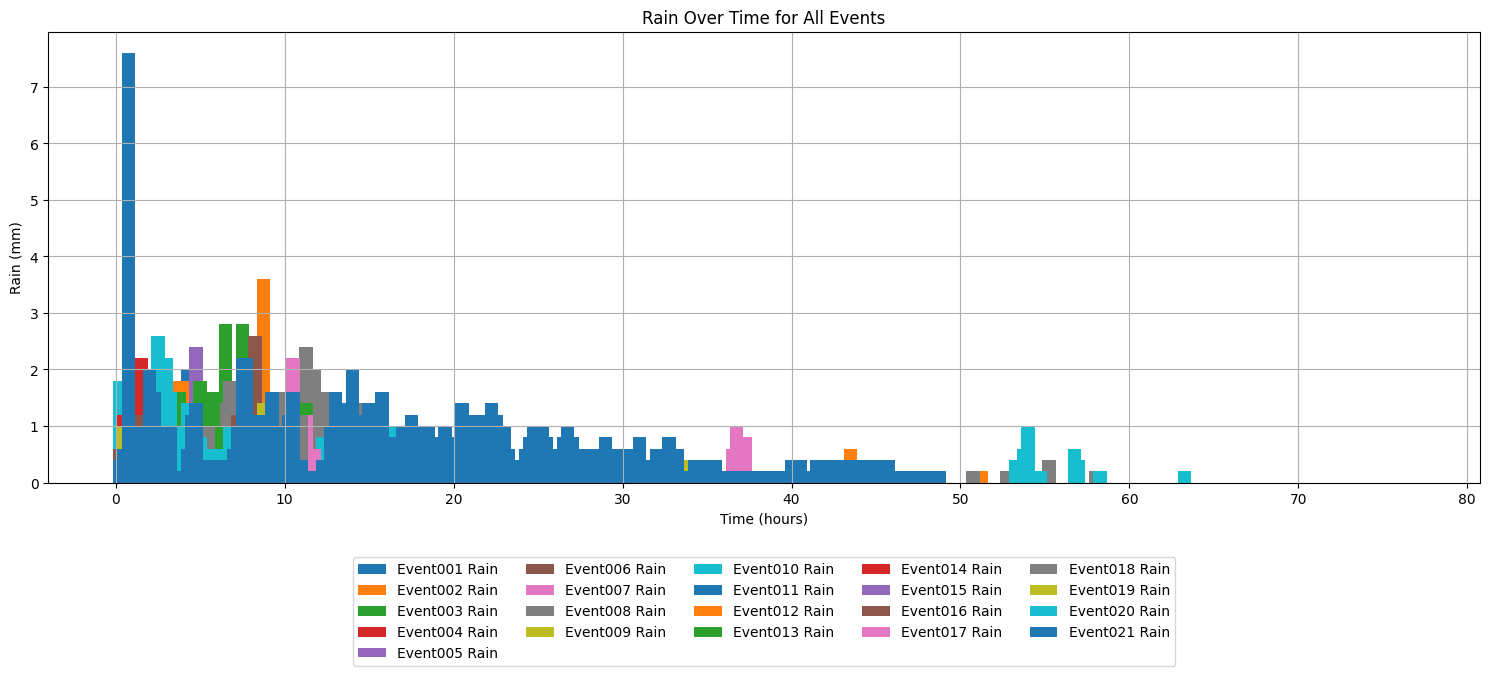

In [ ]:
# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(15, 7))

# Loop through all events and plot their rain data
for i in range(1, N):
    rain_col_name = f'Event{i:03d}_Rain'

    # Check if the column exists in df_events and has valid data
    if rain_col_name in df_events.columns and not df_events[rain_col_name].isnull().all():
        ax.bar(df_events['Time'] / 4, df_events[rain_col_name], label=f'Event{i:03d} Rain')

# Set labels and title for the plot
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Rain (mm)')
ax.set_title('Rain Over Time for All Events')

# Add a legend to differentiate the events

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)

plt.grid(True)
plt.tight_layout()
plt.show()

## Scatter Plot 1: Total Rainfall vs peak Flow

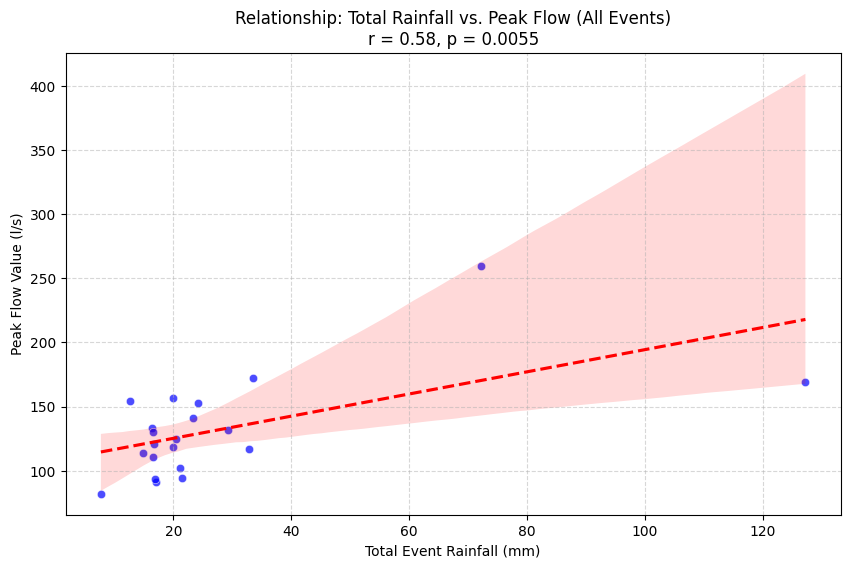

Pearson Correlation Coefficient: 0.58
P-value: 0.00548


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # libray use for scatterplots
import scipy.stats as stats

# Clean data (remove missing values)
data_clean = event_peak_df.dropna(subset=['Total Rainfall (mm)', 'Peak Flow_Value'])

# Create a scatter plot of Total Rainfall vs Peak Flow
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_clean, x='Total Rainfall (mm)', y='Peak Flow_Value', color='blue', alpha=0.7)

# Add a trend line with 95% confidence intervals (ci=95)
sns.regplot(data=data_clean, x='Total Rainfall (mm)', y='Peak Flow_Value',
            scatter=False, color='red', line_kws={'linestyle':'--'}, ci=95)

# alculate correlation and p-value
correlation, p_value = stats.pearsonr(data_clean['Total Rainfall (mm)'], data_clean['Peak Flow_Value'])

# Add labels, title, and statistical results
plt.xlabel('Total Event Rainfall (mm)')
plt.ylabel('Peak Flow Value (l/s)')
plt.title(f'Relationship: Total Rainfall vs. Peak Flow (All Events)\nr = {correlation:.2f}, p = {p_value:.4f}')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f'Pearson Correlation Coefficient: {correlation:.2f}')
print(f'P-value: {p_value:.5f}')

## Scatter Plot 2: Pre-Peak Rainfall vs Peak Flow

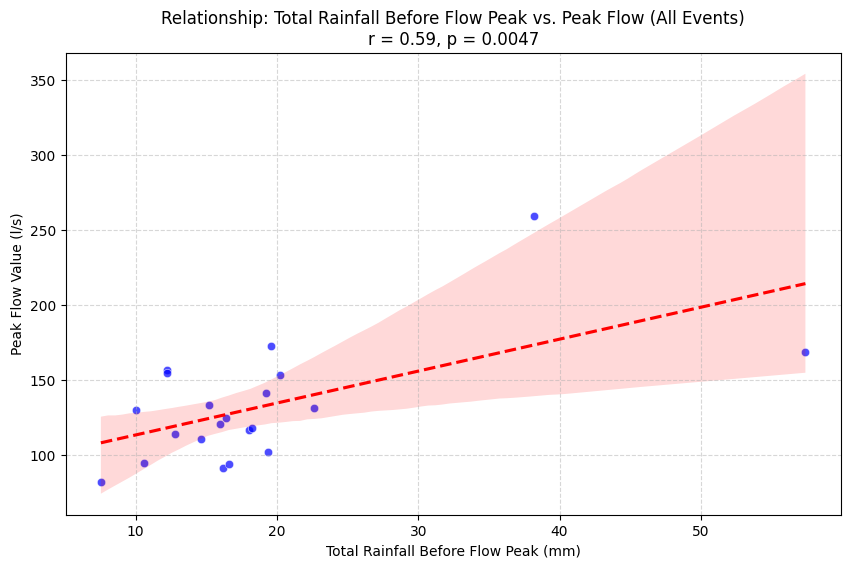

Pearson Correlation Coefficient: 0.59
P-value: 0.00474


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Clean data
data_clean = event_peak_df.dropna(subset=['Total Rainfall Before Flow Peak (mm)', 'Peak Flow_Value'])

# 2. Create a scatter plot of Total Rainfall vs Peak Flow
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_clean, x='Total Rainfall Before Flow Peak (mm)', y='Peak Flow_Value', color='blue', alpha=0.7)

# 3. Add a trend line with 95% confidence intervals (ci=95)
sns.regplot(data=data_clean, x='Total Rainfall Before Flow Peak (mm)', y='Peak Flow_Value',
            scatter=False, color='red', line_kws={'linestyle':'--'}, ci=95)

# 4. Calculate correlation and p-value
correlation, p_value = stats.pearsonr(data_clean['Total Rainfall Before Flow Peak (mm)'], data_clean['Peak Flow_Value'])

# 5. Add labels, title, and statistical results
plt.xlabel('Total Rainfall Before Flow Peak (mm)')
plt.ylabel('Peak Flow Value (l/s)')
plt.title(f'Relationship: Total Rainfall Before Flow Peak vs. Peak Flow (All Events)\nr = {correlation:.2f}, p = {p_value:.4f}')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f'Pearson Correlation Coefficient: {correlation:.2f}')
print(f'P-value: {p_value:.5f}')

## Install Ptitprince libary  for Box Plot Graph

In [ ]:
!pip install ptitprince

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 50.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptitprince: filename=ptitprince-0.3.1-py3-none-any.whl size=16216 sha256=105e89d267ea4866ff12c3c7e3b95bca15e958ab1ca298b61b4ed06251882ae4
  Stored in directory: /root/.cache/pip/wheels/5d/79/49/b89a41fd3d8780ce2c21c7f2debe45f3c6b08d8aef400e3df1
Successfully built ptitprince


### Raincloud Plot for Flow Events

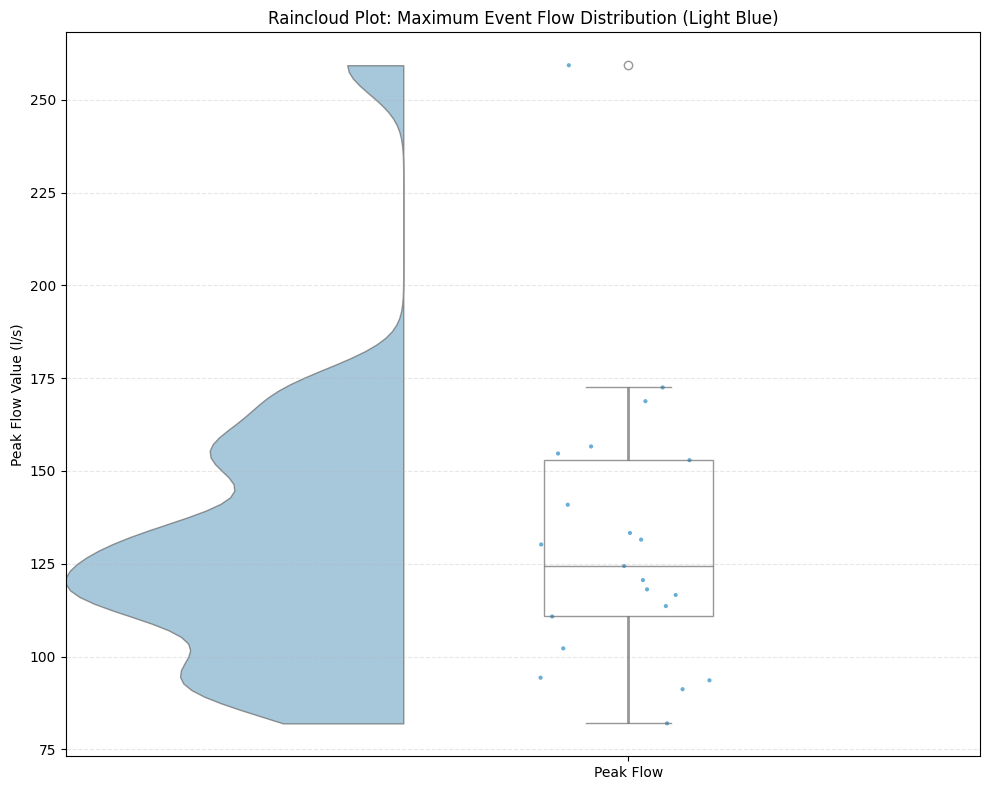

Descriptive Statistics for Event Peaks:


,Peak Flow_Value
count,21.000000
mean,131.814286
std,38.855711
min,82.000000
25%,110.800000
50%,124.400000
75%,152.900000
max,259.300000


In [ ]:
import ptitprince as pt # ibraey used to create raincloud plot
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas for DataFrame creation

# Prepare the peak flow data into a DataFrame with a dummy category for hue
plot_data = pd.DataFrame({
    'Peak Flow_Value': event_peak_df['Peak Flow_Value'].dropna(),
    'Category': 'Peak Flow' # Dummy category for hue
})

# Create the figure
plt.figure(figsize=(10, 8))

# Create the Raincloud plot in light blue, using 'Category' for x and hue, and hiding the legend
ax = pt.RainCloud(x='Category', y='Peak Flow_Value', # Specify x and y from the DataFrame
                  hue='Category', # Assign 'Category' to hue as suggested by the warning
                  data=plot_data, # Pass the DataFrame
                  palette='Blues',
                  bw=.2,
                  width_viol=.6,
                  orient='v',
                  alpha=.65,
                  move=.0) # Removed legend=False, as it causes an AttributeError

# Labels and Title
plt.title('Raincloud Plot: Maximum Event Flow Distribution (Light Blue)')
plt.ylabel('Peak Flow Value (l/s)')
plt.xlabel('') # Clear x-axis label as 'Category' is just a placeholder
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Display Descriptive Statistics
print("Descriptive Statistics for Event Peaks:")
display(plot_data['Peak Flow_Value'].describe())

### Raincloud Plot for Rainfall Events

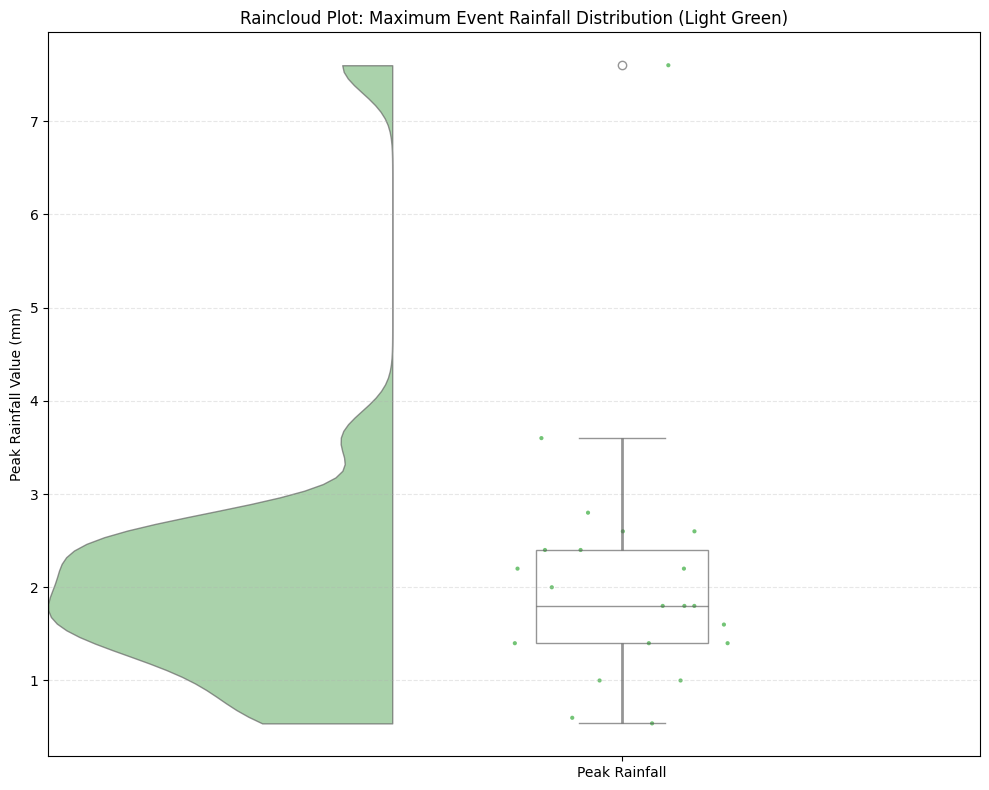

Descriptive Statistics for Event Peaks:


,Peak Rain Value Overall (mm)
count,21.000000
mean,2.130476
std,1.462431
min,0.540000
25%,1.400000
50%,1.800000
75%,2.400000
max,7.600000


In [ ]:
import ptitprince as pt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas for DataFrame creation

# Prepare the peak rainfall data into a DataFrame with a dummy category for hue
plot_data = pd.DataFrame({
    'Peak Rain Value Overall (mm)': event_peak_df['Peak Rain Value Overall (mm)'].dropna(),
    'Category': 'Peak Rainfall' # Dummy category for hue
})

# Create the figure
plt.figure(figsize=(10, 8))

# Create the Raincloud plot in light blue, using 'Category' for x and hue, and hiding the legend
ax = pt.RainCloud(x='Category', y='Peak Rain Value Overall (mm)', # Specify x and y from the DataFrame
                  hue='Category', # Assign 'Category' to hue as suggested by the warning
                  data=plot_data, # Pass the DataFrame
                  palette='Greens',
                  bw=.2,
                  width_viol=.6,
                  orient='v',
                  alpha=.65,
                  move=.0) # Removed legend=False, as it causes an AttributeError

# Labels and Title
plt.title('Raincloud Plot: Maximum Event Rainfall Distribution (Light Green)')
plt.ylabel('Peak Rainfall Value (mm)')
plt.xlabel('') # Clear x-axis label as 'Category' is just a placeholder
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Display Descriptive Statistics
print("Descriptive Statistics for Event Peaks:")
display(plot_data['Peak Rain Value Overall (mm)'].describe())

# Peak Flow Vs Lag Time Analysis

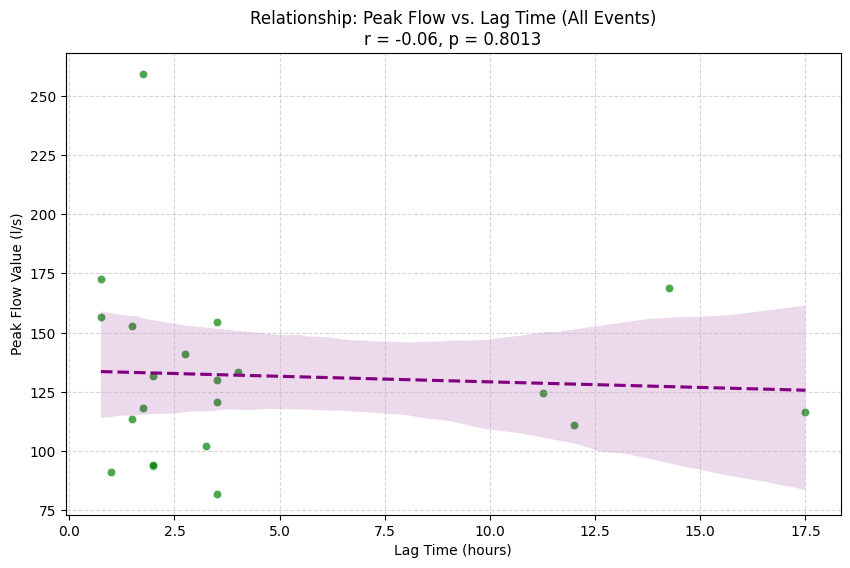

Pearson Correlation Coefficient: -0.06
P-value: 0.80134


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Clean data by removing missing values for the relevant columns
data_clean_lag = event_peak_df.dropna(subset=['Peak Flow_Value', 'Lag Time (hours)'])

# Create a scatter plot of Peak Flow vs. Lag Time
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_clean_lag, x='Lag Time (hours)', y='Peak Flow_Value', color='green', alpha=0.7)

# Add a trend line with 95% confidence intervals
sns.regplot(data=data_clean_lag, x='Lag Time (hours)', y='Peak Flow_Value',
            scatter=False, color='purple', line_kws={'linestyle':'--'}, ci=95)

# Calculate correlation and p-value
correlation_lag, p_value_lag = stats.pearsonr(data_clean_lag['Lag Time (hours)'], data_clean_lag['Peak Flow_Value'])

# Add labels, title, and statistical results
plt.xlabel('Lag Time (hours)')
plt.ylabel('Peak Flow Value (l/s)')
plt.title(f'Relationship: Peak Flow vs. Lag Time (All Events)\nr = {correlation_lag:.2f}, p = {p_value_lag:.4f}')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f'Pearson Correlation Coefficient: {correlation_lag:.2f}')
print(f'P-value: {p_value_lag:.5f}')